In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker 
from matplotlib.ticker import MaxNLocator
import warnings

warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:,.0f}'.format

# Characterizing SLCP offsetting in the voluntary carbon market

The temperature dynamics we characterized for the California program apply anywhere offsetting relies on short-lived climate pollutants (SLCPs). The picture is squishier in the voluntary carbon market (VCM), since offsets in the VCM don't justify emissions that polluters would otherwise have a regulatory obligation to reduce, but we can still characterize the role SLCP crediting plays in the VCM and how that role is changing.

This notebook uses the Berkeley Carbon Trading Project's **[Voluntary Registry Offsets Database (v2026-06)](https://gspp.berkeley.edu/berkeley-carbon-trading-project/offsets-database)**, which includes registry data from the American Carbon Registry (ACR), Architecture for REDD+ Transactions (ART), Climate Action Reserve (CAR), Gold Standard, Isometric (ISO), and Verra (VCS). It looks at:

1. total issuance and retirement by SLCP credit type (methane vs. ODS vs. HFC/other F-gas)
2. change in issuance and retirement by credit type over time
3. market concentration (projects and project developers)

## Load VCM data

In [2]:
vcm_df = pd.read_excel('../timeseries-data/input-data/Voluntary-Registry-Offsets-Database--v2026-06.xlsx', sheet_name='PROJECTS', skiprows=3)

In [3]:
rename = {
    'Project ID': 'project_id',
    'Project Name': 'project_name',
    'Voluntary Registry': 'registry',
    'ARB / WA \nProject': 'arb_wa',
    'Voluntary Status': 'status',
    'Scope': 'scope',
    'Type': 'type',
    'Methodology / Protocol': 'protocol',
    'Region': 'region',
    'Country': 'country',
    'State': 'state',
    'Project Developer': 'developer',
    'Project Owner ': 'owner',
    'Total Credits \nIssued': 'total_issued',
    'Total Credits \nRetired': 'total_retired',
    'Total Credits Remaining': 'total_remaining',
    'First Year of Project (Vintage)': 'project_vintage_yr',
    'Project Listed': 'project_listing_yr',
    'Project Registered ': 'project_registration_yr',
    'Certifications': 'certifications',
}

# the data has three sets of year columns (1996-2026) that get garbled into a funny format
# to avoid duplicates. we need to add them to a rename dict as well. 
years = list(range(1996, 2027))
vintage_cols  = {y: 'issued_vintage_{}'.format(y) for y in years} # credits issued by vintage year (when flux occurs)
retired_cols  = {'{}.1'.format(y): 'retired_{}'.format(y) for y in years} #  credits retired or canceled in each year
remaining_cols = {'{}.2'.format(y): 'remaining_vintage_{}'.format(y) for y in years} # credits remaining by vintage year
issuance_cols = {'{}.3'.format(y): 'issued_{}'.format(y) for y in years} # credits issued by issuance year

year_rename = {}
year_rename.update(vintage_cols)
year_rename.update(retired_cols)
year_rename.update(remaining_cols)
year_rename.update(issuance_cols)

for raw_col in year_rename:
    vcm_df[raw_col] = pd.to_numeric(vcm_df[raw_col], errors='coerce')

# rename full set of interesting columns
full_rename = {**rename, **year_rename}
vcm_df = vcm_df[list(full_rename.keys())].rename(columns=full_rename)

# derive credits retired per vintage year (issued in that vintage, no longer outstanding)
retired_vintage_cols = {y: 'retired_vintage_{}'.format(y) for y in years}
vcm_df[list(retired_vintage_cols.values())] = (
    vcm_df[list(vintage_cols.values())].to_numpy()
    - vcm_df[list(remaining_cols.values())].to_numpy()
)

In [4]:
vcm_df.columns.tolist()

['project_id',
 'project_name',
 'registry',
 'arb_wa',
 'status',
 'scope',
 'type',
 'protocol',
 'region',
 'country',
 'state',
 'developer',
 'owner',
 'total_issued',
 'total_retired',
 'total_remaining',
 'project_vintage_yr',
 'project_listing_yr',
 'project_registration_yr',
 'certifications',
 'issued_vintage_1996',
 'issued_vintage_1997',
 'issued_vintage_1998',
 'issued_vintage_1999',
 'issued_vintage_2000',
 'issued_vintage_2001',
 'issued_vintage_2002',
 'issued_vintage_2003',
 'issued_vintage_2004',
 'issued_vintage_2005',
 'issued_vintage_2006',
 'issued_vintage_2007',
 'issued_vintage_2008',
 'issued_vintage_2009',
 'issued_vintage_2010',
 'issued_vintage_2011',
 'issued_vintage_2012',
 'issued_vintage_2013',
 'issued_vintage_2014',
 'issued_vintage_2015',
 'issued_vintage_2016',
 'issued_vintage_2017',
 'issued_vintage_2018',
 'issued_vintage_2019',
 'issued_vintage_2020',
 'issued_vintage_2021',
 'issued_vintage_2022',
 'issued_vintage_2023',
 'issued_vintage_2024',


In [5]:
# confirm understanding of the relationship between year-based rows 

total_issued = vcm_df[issuance_cols.values()].sum().sum()
total_retired = vcm_df[retired_cols.values()].sum().sum()

total_issued_vintage = vcm_df[vintage_cols.values()].sum().sum()
total_retired_vintage = vcm_df[retired_vintage_cols.values()].sum().sum()
total_remaining_vintage = vcm_df[remaining_cols.values()].sum().sum()

assert (total_issued.round(2) == total_issued_vintage.round(2)), "vintaged issuance disagrees with total issuance"
assert (total_retired.round(2) == total_retired_vintage.round(2)), "vintaged retirement disagrees with total retirement"
assert (total_issued.round(2) == (total_retired + total_remaining_vintage).round(2)), "retirement + remaining != issuance"

print(f"Total issuance: {total_issued:,.0f}") 
print(f"Total retirement: {total_retired:,.0f}") 

Total issuance: 2,654,958,148
Total retirement: 1,561,901,935


## Superpollutant classification

The Berkeley Database classifies their data according to project scope (broader) and project type (narrower). Crediting data is also associated with protocols. These categories aren't perfectly nested. For example, the same protocol can show up across multiple types and scopes. 

We're interested in the trends associated with projects that are likely to correspond to superpollutant reductions — particularly methane and refrigerants. We make that classification at the protocol level, using the scopes and types to help us narrow down on the protocols we want to track. 

In [6]:
# make a little map of scope / type / and corresponding protocols
scope_type_protocols = (
    vcm_df.groupby(['scope', 'type'])['protocol']
    .agg(lambda s: sorted(s.dropna().unique().tolist()))
    .reset_index()
    .sort_values(['scope', 'type'])
)

# add a count of distinct protocols per type
scope_type_protocols['n_protocols'] = scope_type_protocols['protocol'].apply(len)

In [7]:
scope_type_protocols['scope'].unique()

array(['Agriculture', 'Carbon Capture & Storage', 'Chemical Processes',
       'Engineered Removal', 'Forestry & Land Use',
       'Household & Community', 'Industrial & Commercial',
       'Renewable Energy', 'Transportation', 'Waste Management'],
      dtype=object)

We can look through each of these scopes to identify project types that are likely to involve SLCP or broader supperpollutant reductions. The most likely scopes seem to be `Agriculture`, `Chemical Processes`, `Industrial & Commercial`, and `Waste Management`.

In [8]:
scope_type_protocols[scope_type_protocols['scope'] == 'Waste Management']['type'].unique()

array(['Biochar', 'Composting', 'Landfill Methane',
       'Methane Recovery in Wastewater', 'Waste Diversion',
       'Waste Incineration', 'Waste Recycling', 'Waste Reduction'],
      dtype=object)

We can then manually compile potentially relevant project types and see all the associated protocols. 

In [9]:
slcp_project_types = [
    # Methane
    'Manure Methane Digester',
    'Landfill Methane',
    'Methane Recovery in Wastewater',
    'Mine Methane Capture',
    'Biodigesters',
    'Rice Emission Reductions',
    'Leak Detection & Repair in Gas Systems',
    'Waste Gas Recovery',
    'Plugging Oil & Gas Wells',
    'Composting',
    'Feed Additives',

    # HFCs
    'HFC Refrigerant Reclamation',
    'HFC Replacement in Foam Production',
    'Advanced Refrigerants',
    'Refrigerant Leak Detection',
    'HFC23 Destruction',

    # Broader superpollutant framing (N2O, SF6, ODS)
    'SF6 Replacement',
    'N2O Destruction in Adipic Acid Production',
    'N2O Destruction in Nitric Acid Production',
    'Nitrogen Management',
    'Ozone Depleting Substances Recovery & Destruction',
]

unique_protocols = vcm_df.loc[vcm_df['type'].isin(slcp_project_types), 'protocol'].dropna().unique().tolist()
unique_protocols

['Emission reductions through industrial gas substitution',
 'Monitoring, Reporting, and Verification Protocol for the Inland Empire Utilities Agency (IEUA) Anaerobic Digester Project',
 'Monitoring, Reporting and Verification Protocol for Landfill Gas Combustion',
 'Offset Project Methodology for Landfill Methane Collection and Combustion',
 'ACM0014 Treatment of wastewater',
 'Nitrous Oxide Abatement Protocol',
 'ARB Compliance Offset Protocol: Destruction of U.S. Ozone Depleting Substances Banks',
 'ACR Methodology for Quantifying Nitrous Oxide (N2O) Emissions Reductions from Reduced Use of Nitrogen Fertilizer on Agricultural Crops',
 'ARB Compliance Offset Protocol: Capturing and Destroying Methane from Manure Management Systems',
 'ACR Emission Reductions in Rice Management Systems',
 'ARB Compliance Offset Protocol: Mine Methane Capture Projects',
 'AM0065 Replacement of SF6 with alternate cover gas in the magnesium industry',
 'ACR Certified Reclaimed HFC Refrigerants, Propellan

We classify these protocols manually to identify (1) if they do indeed credit SLCP or superpollutant reductions, (2) which gas reductions are credited, and (3) whether that categorically corresponds to the destruction of a short-lived, long-lived, or mixed set of gases. That work was done in a google sheet for ease: https://docs.google.com/spreadsheets/d/1MRgh3B-uhsgnHvQKmU3sG3yYusc1-06gAic6TnhzB70/edit?gid=0#gid=0. We can read in the classification from a csv. 

In [10]:
superpollutant_protocols = pd.read_csv('../timeseries-data/input-data/vcm_protocol_classification.csv')
superpollutant_protocols

,protocol_name,url,program,gases_inferred,slcp_class,notes
0,"Monitoring, Reporting and Verification Protoco...",NaN,ACR,CH4,short-lived,Methodology not available by name on ACR website
1,Offset Project Methodology for Landfill Methan...,NaN,ACR,CH4,short-lived,Methodology not available by name on ACR website
2,ACM0014 Treatment of wastewater,https://cdm.unfccc.int/methodologies/DB/PPKHX1...,CDM,CH4,short-lived,NaN
3,Nitrous Oxide Abatement Protocol,NaN,ACR,N2O,long-lived,Methodology not available by name on ACR websi...
4,ARB Compliance Offset Protocol: Destruction of...,https://ww2.arb.ca.gov/sites/default/files/bar...,ARB,"CFC, HCFC",mixed,Two versions; no substantive difference on inf...
...,...,...,...,...,...,...
65,AM0080 Mitigation of greenhouse gases emission...,https://cdm.unfccc.int/methodologies/DB/6DITU9...,CDM,CH4,short-lived,NaN
66,VM0051 Improved Management in Rice Production ...,https://verra.org/methodologies/improved-manag...,VCS,CH4,short-lived,NaN
67,VM0022 Quantifying N2O Emissions Reductions in...,https://verra.org/methodologies/vm0022-quantif...,VCS,N2O,long-lived,NaN
68,AMS-III.E. Avoidance of methane production fro...,https://cdm.unfccc.int/methodologies/DB/AZB89E...,CDM,CH4,short-lived,NaN


Although we handle each protocol separately, many projects that are developed under CDM protocols are associated with more than one "atomic" protocol. For example, [VCS5986](https://registry.verra.org/verra/public/program/VCS/projects/5986) is associated with a bundle three different CDM protocols: AMS-I.C; AMS-III.D; AMS-III.AO. In this particular case, two protocols in the bundle are for crediting methane, but one of them is for crediting less CO2 intensive thermal energy production. There aren't too many of these, but worth watching out for these bundles throughout the rest of the anlysis, and can exclude these projects for a maximally conservative estimate of superpollutant activity. 

It's also likely that we're missing protocols that credit minor superpollutants reductions alongside CO2 reductions — like some soil carbon protocols. Excluding these contributes to a conservative estimate of superpollutant activity. 

To merge the `slcp_protocol` information with our bigger `vcm_df`, we have to handle the protocol bundles again. 

In [11]:
# explode vcm_df's protocol strings to atomic, keeping the original row index
exploded = (
    vcm_df['protocol']
    .fillna('')
    .str.split(';')
    .explode()
    .str.strip()
    .rename('protocol_atomic')
    .to_frame()
)
exploded.index.name = 'vcm_idx'
exploded = exploded.reset_index()

# left-merge the superpollutant_protocols classification on the atomic protocol rows
merged = exploded.merge(
    superpollutant_protocols,
    how='left',
    left_on='protocol_atomic',
    right_on='protocol_name',
)

# collapse back to one row per original vcm_df row
agg = merged.groupby('vcm_idx').agg(
    slcp_classes=('slcp_class', lambda s: sorted(s.dropna().unique())),
    gases=('gases_inferred', lambda s: sorted(s.dropna().unique())),
    n_superpollutant_protocols=('slcp_class', 'count'),   # count ignores NaN
    n_protocols=('protocol_atomic', lambda s: (s != '').sum()),
)

# attach back to vcm_df — left join preserves every original row
vcm_df = vcm_df.join(agg)
vcm_df['has_superpollutant'] = vcm_df['n_superpollutant_protocols'] > 0
vcm_df['only_superpollutant'] = (vcm_df['has_superpollutant'] & (vcm_df['n_superpollutant_protocols'] == vcm_df['n_protocols']))

In [12]:
# check no rows were lost in the operation
assert (vcm_df['total_issued'].sum().round(2) == total_issued.round(2)), "lost some rows; total issuance has drifted"

# sanity: flag should be a minority, and should agree with the class labels
sp = vcm_df[vcm_df['has_superpollutant']]
bundled = sp['n_protocols'] > 1
mixed_bundle = bundled & (sp['n_superpollutant_protocols'] < sp['n_protocols'])

print(f"{vcm_df['has_superpollutant'].sum():,} of {len(vcm_df):,} projects "
      f"credit at least one superpollutant protocol")
print(f"{bundled.sum():,} of those bundle 2+ protocols ")
print(f"{mixed_bundle.sum():,} bundle a superpollutant protocol with a non-superpollutant one ")

2,402 of 11,468 projects credit at least one superpollutant protocol
221 of those bundle 2+ protocols 
166 bundle a superpollutant protocol with a non-superpollutant one 


And to build our intuition about our classification, we can get a sense for what percentage of the scopes we thought were likely to have slcps were "matched" — versus the other scopes! 

In [13]:
# match rate restricted to the scopes the classification was based on
target_scopes = ['Agriculture', 'Chemical Processes','Industrial & Commercial', 'Waste Management']

in_scope_idx = vcm_df.index[vcm_df['scope'].isin(target_scopes)]
in_scope = merged[merged['vcm_idx'].isin(in_scope_idx)]

print('in-scope match rate:', in_scope['slcp_class'].notna().mean())
print('out-of-scope match rate:',
      merged.loc[~merged['vcm_idx'].isin(in_scope_idx), 'slcp_class'].notna().mean())

in-scope match rate: 0.7043580683156655
out-of-scope match rate: 0.010583254938852305


## Breakdown by superpollutant bucket

One way to understand superpollutant trends in the VCM is to focus on four big gas buckets: 
- short-lived pollutants like CH4 that have a atmospheric lifetime <20 years
- long-lived pollutants like N2O that have an atmospheric lifetime >20 years
- CO2 
- mixed / unresolved credits (where we can't actually tell what's being crediting unless we dig in at the project level)

Questions we're interested in: 

- what's cumulative issuance and retirement by gas bucket?
- what's the share of total issuance and retirement for each gas bucket w.r.t. the voluntary market as a whole?
- do some gas buckets have more "backstock" than others? 
- how old it that backstock?
- have trends in issuance or retirement looked different across the gas buckets?

Section takeaways: 
- SLCPs have represented about 11% of all market issuance to-date (10% of retirements). Long-lived superpollutants projects have played a much smaller role at about 2% of issuance. 
- Both the absolute issuance and absolute retirement numbers for superpollutant credits grown significantly over the last five years. (Eyeballing it, their share of the total market has also grown, though not precipitously). Over 60% of all the superpollutant credits generated have been issued since 2021. 

In [14]:
# collapse each project's slcp_classes list into a single label.

def project_class(v, only_sp):
    if not isinstance(v, (list, tuple)) or len(v) == 0:
        return 'not_superpollutant'
    if not only_sp:
        return 'partial' # bundle spaning superpollutant and non-superpollutant  protocols
    s = set(v)
    if s == {'short-lived'}: return 'short-lived'
    if s == {'long-lived'}:  return 'long-lived'
    return 'mixed'          # {'mixed'}, or bundle spanning lifetime bands

vcm_df['slcp_project_class'] = [
    project_class(v, o)
    for v, o in zip(vcm_df['slcp_classes'], vcm_df['only_superpollutant'])
]

CLASSES = ['short-lived', 'long-lived', 'mixed', 'partial']
VALS = ['total_issued', 'total_retired']

summary = (
    vcm_df.groupby('slcp_project_class')[VALS]
    .sum()
    .reindex(CLASSES + ['not_superpollutant'])
    .fillna(0)
)
summary.loc['superpollutant_lower'] = summary.loc[['short-lived', 'long-lived', 'mixed']].sum()
summary.loc['superpollutant_upper'] = summary.loc[CLASSES].sum()
summary.loc['all_vcm'] = [total_issued, total_retired]

summary['pct_market_issued']  = 100 * summary['total_issued']  / total_issued
summary['pct_market_retired'] = 100 * summary['total_retired'] / total_retired

assert summary.loc['superpollutant_upper'].add(summary.loc['not_superpollutant']) \
        .round(2).eq(summary.loc['all_vcm'].round(2)).all()

summary.round(2)

,total_issued,total_retired,pct_market_issued,pct_market_retired
slcp_project_class,,,,
short-lived,"293,499,129","148,891,019",11,10
long-lived,"64,473,760","40,828,221",2,3
mixed,"65,816,911","35,901,238",2,2
partial,"9,738,390","6,259,739",0,0
not_superpollutant,"2,221,429,958","1,330,021,718",84,85
superpollutant_lower,"423,789,800","225,620,478",16,14
superpollutant_upper,"433,528,190","231,880,217",16,15
all_vcm,"2,654,958,148","1,561,901,935",100,100


We can also look at trends across these gas classes over time. In all of these plots, we're looking at issuance year (rather than credit vintage year). 

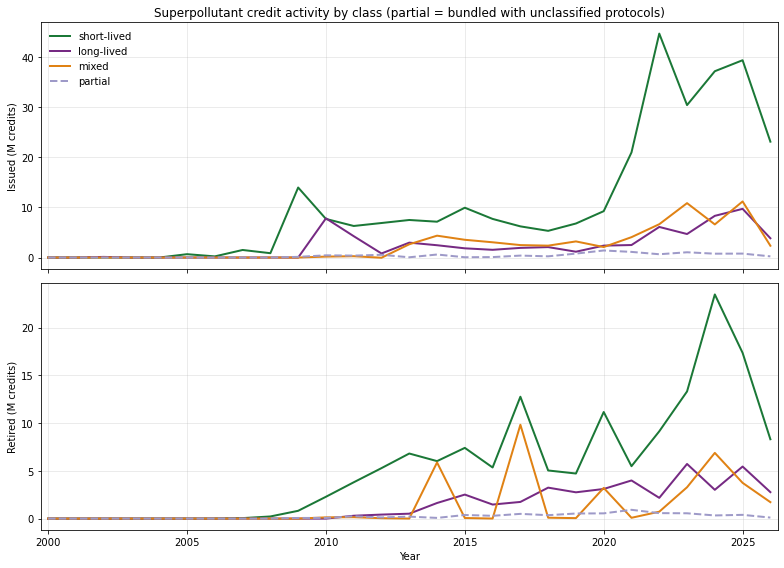

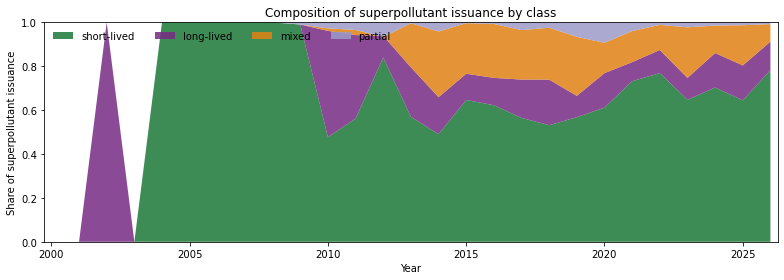

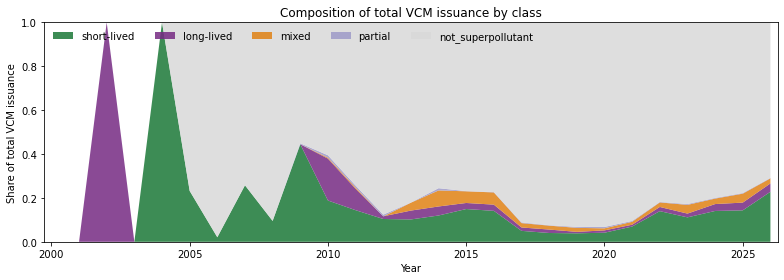

In [15]:
years = list(range(2000, 2027))
issuance_cols = [f'issued_{y}' for y in years]
retired_cols  = [f'retired_{y}'  for y in years]

CLASS_ORDER = ['short-lived', 'long-lived', 'mixed', 'partial', 'not_superpollutant']
SP_CLASSES  = CLASS_ORDER[:4]

# sum each year column within each class -> year x class matrices
def class_ts(cols):
    return (
        vcm_df.groupby('slcp_project_class')[cols].sum()
        .rename(columns=lambda c: int(c.split('_')[1]))
        .reindex(CLASS_ORDER)
        .fillna(0)
        .T
    )

issued_ts_all  = class_ts(issuance_cols)
retired_ts_all = class_ts(retired_cols)
issued_ts, retired_ts = issued_ts_all[SP_CLASSES], retired_ts_all[SP_CLASSES]

colors = {'short-lived': '#1b7837', 'long-lived': '#762a83',
          'mixed': '#e08214', 'partial': '#9e9ac8',
          'not_superpollutant': '#d9d9d9'}

# credit activity by class
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
for ax, ts, label in zip(axes, [issued_ts, retired_ts], ['Issued', 'Retired']):
    for cls in ts.columns:
        ax.plot(ts.index.to_numpy(), (ts[cls] / 1e6).to_numpy(),
                label=cls, color=colors[cls], lw=2,
                ls='--' if cls == 'partial' else '-')
    ax.set_ylabel(f'{label} (M credits)')
    ax.grid(alpha=0.3)
    ax.margins(x=0.01)
axes[0].set_title('Superpollutant credit activity by class '
                  '(partial = bundled with unclassified protocols)')
axes[0].legend(frameon=False)
axes[1].set_xlabel('Year')
plt.tight_layout()
plt.show()

# superpollutant credit share by class
share = issued_ts.div(issued_ts.sum(axis=1), axis=0).fillna(0)
fig, ax = plt.subplots(figsize=(11, 4))
ax.stackplot(share.index.to_numpy(), share.to_numpy().T,
             labels=list(share.columns),
             colors=[colors[c] for c in share.columns], alpha=0.85)
ax.set_ylim(0, 1); ax.margins(x=0.01)
ax.set_ylabel('Share of superpollutant issuance')
ax.set_xlabel('Year')
ax.set_title('Composition of superpollutant issuance by class')
ax.legend(loc='upper left', frameon=False, ncol=4)
plt.tight_layout()
plt.show()

# total market credit share by class
market_share = issued_ts_all.div(issued_ts_all.sum(axis=1), axis=0).fillna(0)
fig, ax = plt.subplots(figsize=(11, 4))
ax.stackplot(market_share.index.to_numpy(), market_share.to_numpy().T,
             labels=list(market_share.columns),
             colors=[colors[c] for c in market_share.columns], alpha=0.85)
ax.set_ylim(0, 1); ax.margins(x=0.01)
ax.set_ylabel('Share of total VCM issuance')
ax.set_xlabel('Year')
ax.set_title('Composition of total VCM issuance by class')
ax.legend(loc='upper left', frameon=False, ncol=5)
plt.tight_layout()
plt.show()

In [16]:
tbl = issued_ts.copy()
tbl['total'] = tbl.sum(axis=1)
tbl['cumulative_total'] = tbl['total'].cumsum()
tbl['cumulative_pct'] = 100 * (tbl['cumulative_total'] / tbl['total'].sum())
tbl.round(2)

slcp_project_class,short-lived,long-lived,mixed,partial,total,cumulative_total,cumulative_pct
2000,0,0,0,0,0,0,0
2001,0,0,0,0,0,0,0
2002,0,"125,000",0,0,"125,000","125,000",0
2003,0,0,0,0,0,"125,000",0
2004,500,0,0,0,500,"125,500",0
2005,"668,510",0,0,0,"668,510","794,010",0
2006,"229,061",0,0,0,"229,061","1,023,071",0
2007,"1,506,410",0,0,0,"1,506,410","2,529,481",1
2008,"864,015",0,0,0,"864,015","3,393,496",1
2009,"13,957,610",0,0,"136,904","14,094,514","17,488,010",4


## Plotting functions

Plots to get at the following questions by superpollutant class (created with help from Claude): 
- Do certain protocols or projects dominate credit issuance — cumulatively, or during recent years?
- Do certain protocols or projects dominate credit retirement — cumulatively, or during recent years?
- What's the composition of the SLCP credit backstock (protocols / projects)? What vintage years do those credits represent? Are people buying from those protocols and projects? 

In [17]:
_BASE = ['#1b7837', '#762a83', '#e08214', '#2166ac', '#b2182b', '#5aae61',
         '#9970ab', '#f1a340', '#67a9cf', '#d6604d']
_EXTRA = [matplotlib.colors.to_hex(plt.get_cmap('tab20')(i)) for i in range(20)]
_POOL = _BASE + [c for c in _EXTRA if c not in _BASE]
OTHER = 'All other protocols'

def _stack(ts, top, other=OTHER):
    top = [c for c in top if c in ts.columns]
    d = ts[top].copy()
    rest = ts.drop(columns=top)
    d[other] = rest.sum(axis=1) if len(rest.columns) else 0.0
    return d.div(d.sum(axis=1), axis=0)

def short(s, n=70):
    return s if len(s) <= n else s[:n].rstrip() + '…'

def stacked_shares(df, start, end, top_n, class_label='',
                   shared_protocols=True, rank_by='issued', colors=None):
    PANELS = [('issued',  'credits issued by year'),
              ('retired', 'credits retired by year')]
    LEGEND_NCOL, LEGEND_FONTSIZE = 2, 11

    def _ts(prefix):                                   # now closes over df/start/end
        cols = [f'{prefix}_{y}' for y in range(start, end + 1)]
        return (df.groupby('protocol')[cols].sum()
                  .rename(columns=lambda c: int(c.rsplit('_', 1)[1])).T)

    ts_by_panel = {p: _ts(p) for p, _ in PANELS}

    if shared_protocols:
        named = ts_by_panel[rank_by].sum().nlargest(top_n).index.tolist()
        top_by_panel = {p: named for p, _ in PANELS}
    else:
        top_by_panel = {p: ts_by_panel[p].sum().nlargest(top_n).index.tolist()
                        for p, _ in PANELS}
        named = []
        for p, _ in PANELS:
            for x in top_by_panel[p]:
                if x not in named:
                    named.append(x)
        top_by_panel = {p: [x for x in named if x in top_by_panel[p]] for p, _ in PANELS}

    COLORS = dict(colors) if colors else {}            
    for i, p in enumerate(named):
        COLORS.setdefault(p, _POOL[i % len(_POOL)])
    COLORS[OTHER] = '#bdbdbd'

    fig, axes = plt.subplots(len(PANELS), 1, figsize=(13, 3.4 * len(PANELS)),
                             sharex=True, squeeze=False)
    axes = axes.ravel()
    for ax, (prefix, lab) in zip(axes, PANELS):
        sh = _stack(ts_by_panel[prefix], top_by_panel[prefix])
        ax.stackplot(sh.index.to_numpy(), np.nan_to_num(sh.to_numpy().T),
                     colors=[COLORS[c] for c in sh.columns], alpha=0.85)
        ax.set_ylim(0, 1)
        ax.margins(x=0.01)
        ax.set_ylabel('Share of credits', fontsize=9)
        ax.set_title(f'{lab} — top {top_n} protocols')
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    handles = [plt.Rectangle((0, 0), 1, 1, color=COLORS[p]) for p in named + [OTHER]]
    fig.legend(handles, [short(p) for p in named + [OTHER]],
               loc='upper center', bbox_to_anchor=(0.5, -0.01), ncol=LEGEND_NCOL,
               frameon=False, fontsize=LEGEND_FONTSIZE, handlelength=1.4,
               handleheight=1.0, labelspacing=0.7, columnspacing=1.8)
    axes[-1].set_xlabel('Year')
    plt.tight_layout()
    plt.show()

    for prefix, _ in PANELS:
        others = [q for q, _ in PANELS if q != prefix]
        only = [p for p in top_by_panel[prefix]
                if not any(p in top_by_panel[o] for o in others)]
        

    return named, COLORS, ts_by_panel

In [18]:
def cum_snapshot(df, start, end, top_n, class_label='', colors=None,
                 legend_ncol=2, legend_fontsize=10):
    def _mat(prefix):
        cols = [f'{prefix}_{y}' for y in range(start, end + 1)]
        return (df.groupby('protocol')[cols].sum()
                  .rename(columns=lambda c: int(c.rsplit('_', 1)[1])).T)

    iss, ret = _mat('issued'), _mat('retired')
    cum_named = iss.sum().nlargest(top_n).index.tolist()

    COLORS = dict(colors) if colors else {}
    for i, p in enumerate(cum_named):
        COLORS.setdefault(p, _POOL[i % len(_POOL)])
    COLORS[OTHER] = '#bdbdbd'

    def _with_other(m):
        keep = [c for c in cum_named if c in m.columns]
        d = m[keep].copy()
        d[OTHER] = m.drop(columns=keep).sum(axis=1)
        return d

    cum_i, cum_r = _with_other(iss.cumsum()), _with_other(ret.cumsum())

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5),
                             gridspec_kw={'width_ratios': [1.5, 1]})
    ax = axes[0]
    for c in cum_i.columns:
        ax.plot(cum_i.index.to_numpy(), (cum_i[c] / 1e6).to_numpy(),
                color=COLORS[c], lw=2, ls='--' if c == OTHER else '-')
    ax.set_xlabel('Year')
    ax.set_ylabel('Cumulative issued (M credits)')
    ax.set_title(f'{class_label}{": " if class_label else ""}cumulative issuance by protocol')
    ax.grid(alpha=0.3)
    ax.margins(x=0.01)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax2 = axes[1]
    issued  = cum_i.iloc[-1] / 1e6
    retired = (cum_r.iloc[-1] / 1e6).reindex(issued.index).fillna(0)
    order = issued.sort_values().index
    issued, retired = issued[order], retired[order]
    ypos = np.arange(len(order))

    ax2.barh(ypos, issued.to_numpy(),  color=[COLORS[c] for c in order], alpha=0.30)
    ax2.barh(ypos, retired.to_numpy(), color=[COLORS[c] for c in order], alpha=0.95)
    ax2.set_yticks(ypos)
    ax2.set_yticklabels([short(i, 44) for i in order], fontsize=8)
    for i, (iv, rv) in enumerate(zip(issued.to_numpy(), retired.to_numpy())):
        ax2.text(iv * 1.02, i, f'{100 * rv / iv:.0f}%' if iv else '—',
                 va='center', fontsize=8, color='0.3')
    ax2.set_xlabel('Cumulative issuance (M)')
    ax2.set_title(f'Remaining (pale) vs retired (solid), through {end}')
    ax2.grid(axis='x', alpha=0.3)
    ax2.margins(x=0.14)

    handles = [plt.Rectangle((0, 0), 1, 1, color=COLORS[p]) for p in cum_named + [OTHER]]
    handles += [plt.Rectangle((0, 0), 1, 1, color='0.45', alpha=0.30),
                plt.Rectangle((0, 0), 1, 1, color='0.45', alpha=0.95)]
    labels = [short(p) for p in cum_named + [OTHER]] + ['(pale) remaining', '(solid) retired']
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.01),
               ncol=legend_ncol, frameon=False, fontsize=legend_fontsize,
               handlelength=1.6, labelspacing=0.6, columnspacing=1.8)
    plt.tight_layout()
    plt.show()

In [19]:
def outstanding_credits(df, start, end, named, colors=None,
                        class_label='', legend_ncol=2, legend_fontsize=10,
                        label_chars=70):
    cols = [f'remaining_vintage_{y}' for y in range(start, end + 1)]
    rem = (df.groupby('protocol')[cols].sum()
             .rename(columns=lambda c: int(c.rsplit('_', 1)[1])).T)

    COLORS = dict(colors) if colors else {}
    for i, p in enumerate(named):
        COLORS.setdefault(p, _POOL[i % len(_POOL)])
    COLORS[OTHER] = '#bdbdbd'

    stack_order = [p for p in named if p in rem.columns]
    plot_df = rem[stack_order].copy()                      # not `df`
    rest = rem.drop(columns=stack_order)
    plot_df[OTHER] = rest.sum(axis=1) if len(rest.columns) else 0.0
    plot_df = plot_df / 1e6

    fig, ax = plt.subplots(figsize=(13, 5.5))
    bottom = np.zeros(len(plot_df))
    for c in plot_df.columns:
        ax.bar(plot_df.index.to_numpy(), plot_df[c].to_numpy(), bottom=bottom,
               color=COLORS[c], width=0.82, edgecolor='white', linewidth=0.4)
        bottom += plot_df[c].to_numpy()

    ax.set_xlabel('Vintage year')
    ax.set_ylabel('Credits remaining (M)')
    ax.set_title(f'{class_label}{" " if class_label else ""}credits still outstanding, '
                 f'by vintage year and protocol')
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.margins(x=0.01)
    ax.text(0.99, 0.95, f'total outstanding: {plot_df.sum().sum():,.1f}M',
            transform=ax.transAxes, ha='right', va='top', fontsize=9, color='0.3')

    handles = [plt.Rectangle((0, 0), 1, 1, color=COLORS[p]) for p in stack_order + [OTHER]]
    fig.legend(handles, [short(p, label_chars) for p in stack_order + [OTHER]],
               loc='upper center', bbox_to_anchor=(0.5, -0.01), ncol=legend_ncol,
               frameon=False, fontsize=legend_fontsize, handlelength=1.4,
               labelspacing=0.6, columnspacing=1.8)
    plt.tight_layout()
    plt.show()

    # vintage-age profile of the outstanding stock
    tot = plot_df.sum(axis=1)
    age = pd.DataFrame({'remaining_M': tot,
                        'age_yrs': end - tot.index,
                        'pct': 100 * tot / tot.sum()})
    print(f'weighted mean vintage age: '
          f'{np.average(age["age_yrs"], weights=age["remaining_M"]):.1f} years')

## Unpacking short-lived trends by protocol

Let's dig into the short-lived credit class. Given the short atmmospheric lifetime of the associated gas fluxes, this credit class is the most interesting from the perspective of temporal mismatches in offsetting, and how they might affect temperature outcomes. 

Takeaways: Landfill credits from [CAR U.S. Landfill Protocol](https://climateactionreserve.org/how/protocols/waste/us-landfill/) and [ACC001](https://cdm.unfccc.int/methodologies/DB/JPYB4DYQUXQPZLBDVPHA87479EMY9M) dominate all-time SLCP action, but a few recent growth categories seem worth watching.
- [ACR Transition to Advanced Formulation Blowing Agents in Foam Manufacturing and Use](https://acrcarbon.org/wp-content/uploads/2023/03/ACR-FBA-v3.0.pdf) saw a rapid rise in use, the timing of which looks like it might correspond with the development of version 2 of that protocol in 2018. ACR deactivated the protocol at the end of 2024, so I wouldn’t expect it to continue to play a growing role — but it will be interesting to see if there’s sustained demand for the outstanding credits. The bulk of projects came online 2016-2023. Notably, these credits are awarded for using a lower GWP blowing agent in the production of foam. Common baseline blowing agents per the protocol include HFC-152a, HFC-365mfc, HFC245fa, and HFC134a — which are pretty short lived (1.5-13.4 years).
- [AM0023 for leak detection and repair in gas systems](https://cdm.unfccc.int/methodologies/DB/PZN9ZCTGF3KHFH0W21NY0NYL6X5CIR)is a CDM protocol that was last updated in 2011 that’s now seemingly booming under Verra. It has only 9 credited projects under it, seven of which are located in Bangladesh, which I believe has a state-owned oil and gas sector. As an aside, it looks like some of these credits are in [BP’s carbon credit portfolio](https://www.bp.com/en_gb/carbon-connect/home/our-carbon-credit-portfolio/our-current-portfolio/titas-gas-methane-leak-reduction.html). 
- [ACR Plugging of Orphaned Oil and Gas (OOG) Wells](https://acrcarbon.org/methodology/plugging-orphaned-oil-and-gas-wells-2/) is actively being updated, but the first version has a notable spike in use. 

In [27]:
sl = vcm_df[vcm_df['slcp_project_class'] == 'short-lived']
year_start = 2000
year_end = 2025
top_n = 15

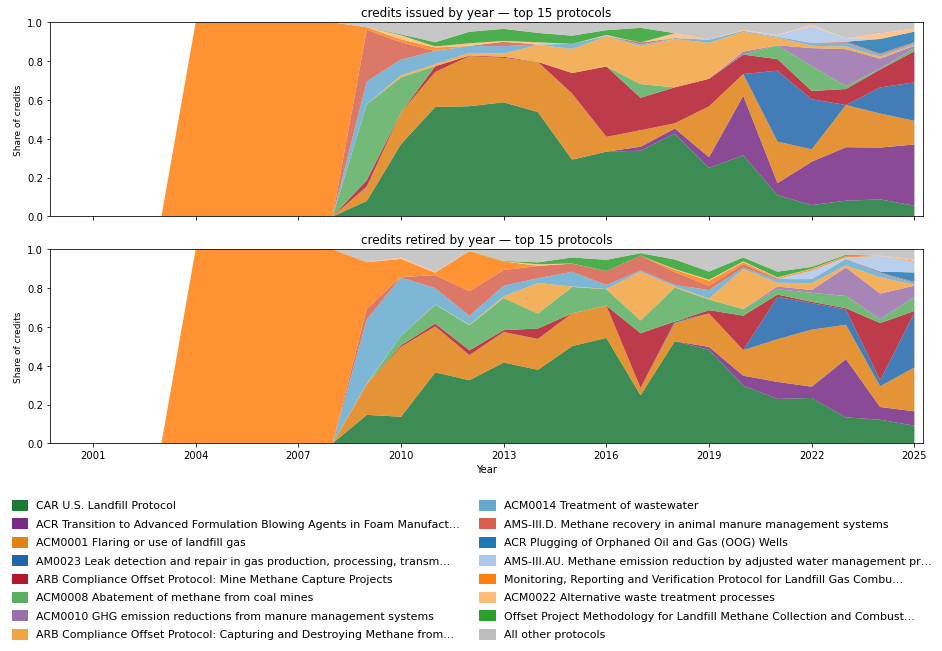

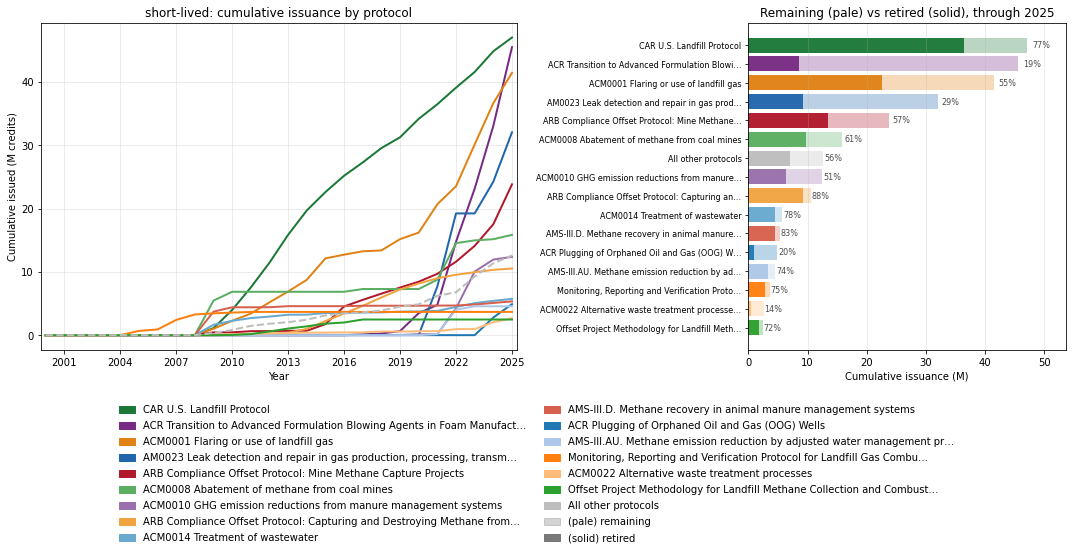

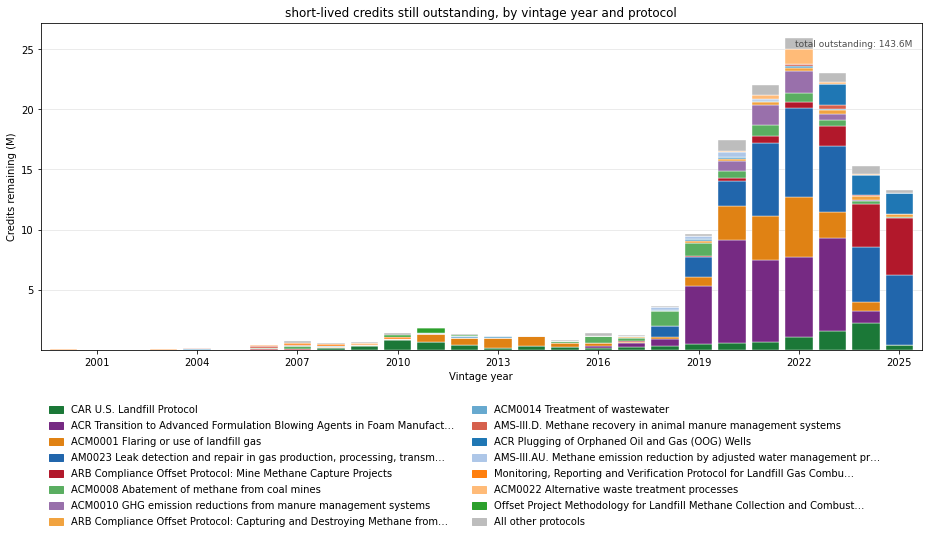

weighted mean vintage age: 4.0 years


In [28]:
named, colors, ts = stacked_shares(sl, year_start, year_end, top_n, class_label='short-lived')
cum_snapshot(sl, year_start, year_end, top_n, class_label='short-lived', colors=colors)
outstanding_credits(sl, year_start, year_end, named=named, colors=colors, class_label='short-lived')

## Unpacking long-lived trends by protocol

Takeaways: 
- Huge recent surge of credits under the [CAR U.S. Adipic Acid Production protocol](https://climateactionreserve.org/how/protocols/industrial/adipic-acid-production/), which accounts for essentially the entire recent growth of the long-lived class. Interestingly, it’s entirely driven by a single project ([CAR1480](https://thereserve2.apx.com/mymodule/reg/TabDocuments.asp?r=111&ad=Prpt&act=update&type=PRO&aProj=pub&tablename=doc&id1=1480)), the only credited project under the protocol. All told, it works out to more than a third of all long-lived superpollutant issuances from one project in 5 years!
- [ACR Destruction of Ozone Depleting Substances from International Sources](https://acrcarbon.org/methodology/destruction-of-ozone-depleting-substances-from-international-sources/) is also on the upswing. 

In [22]:
ll = vcm_df[vcm_df['slcp_project_class'] == 'long-lived']
year_start = 2005
year_end = 2025
top_n = 6

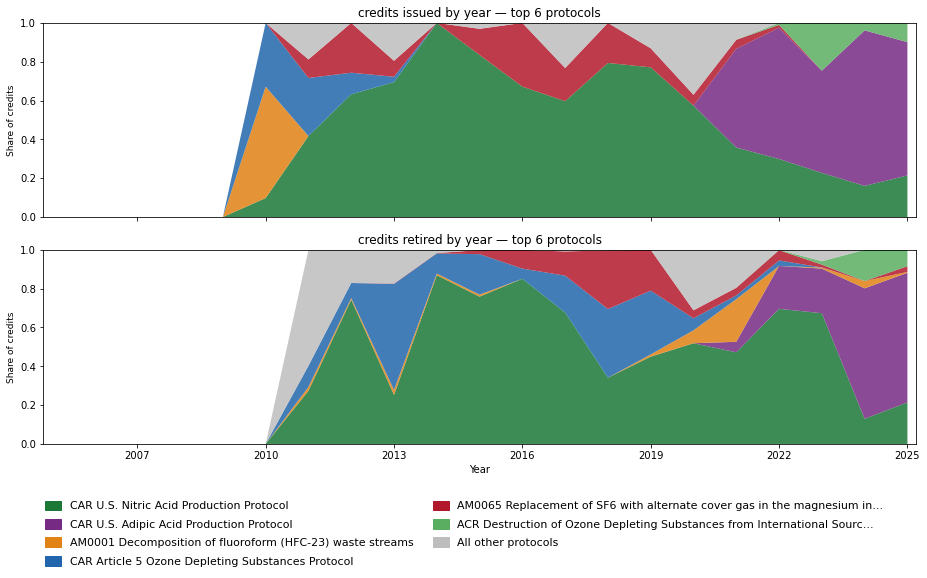

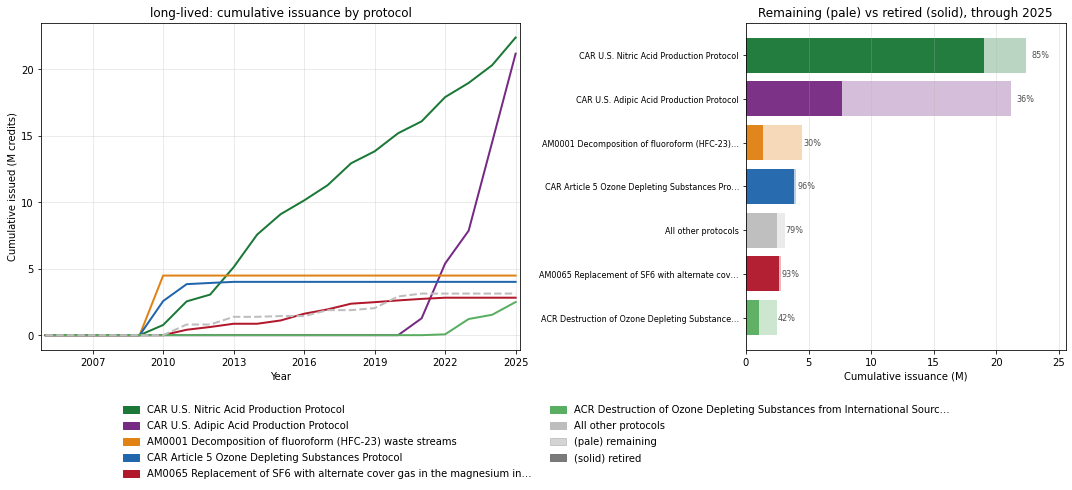

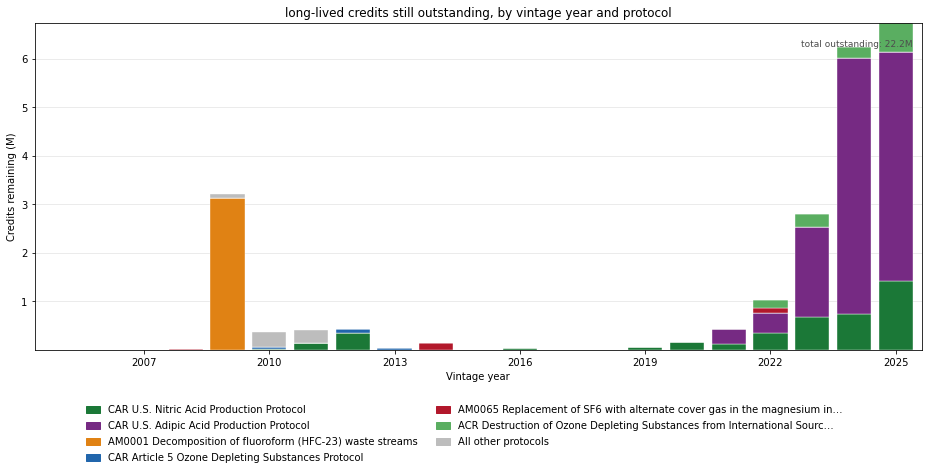

weighted mean vintage age: 4.0 years


In [23]:
named, colors, ts = stacked_shares(ll, year_start, year_end, top_n, class_label='long-lived')
cum_snapshot(ll, year_start, year_end, top_n, class_label='long-lived', colors=colors)
outstanding_credits(ll, year_start, year_end, named=named, colors=colors, class_label='long-lived')

## Exploring protocol level trends

At the protocol level, it can be useful to get a quick picture of the level of concentration in particular projects or by particular developers. In this section, you can specify the protocol and get a quick peek. 

Check out `CAR U.S. Adipic Acid Production Protocol` for an example of full concentration, or `CAR U.S. Landfill Protocol` for an example of more distributed activity. 

In [24]:
protocol = 'CAR U.S. Landfill Protocol'
subset = vcm_df[vcm_df['protocol'] == protocol]

In [25]:
PLACEHOLDERS = {'Multiple Proponents', 'Converted from other GHG program',
                'Not provided', 'Other', ''}

def concentration_profile(subset, label='', by=('project_id', 'developer', 'region'),
                          value='total_issued', top_k=5, extra_cols=('project_name',)):
    """At-a-glance concentration of a value across projects / developers / regions."""
    total = subset[value].sum()
    print(f'{label or "subset"}: {len(subset):,} projects | {total/1e6:,.2f}M {value}\n')

    def _clean(s, dim):
        if dim == 'developer':                      # placeholders aren't real entities
            s = s[~s[dim].fillna('').str.strip().isin(PLACEHOLDERS)]
        return s

    rows, tops = [], {}
    for dim in by:
        s = _clean(subset.copy(), dim)
        key = s[dim].fillna('(missing)').astype(str).str.strip()
        g = s.groupby(key)[value].sum()
        g = g[g > 0].sort_values(ascending=False)
        if g.empty:
            continue
        share = g / total
        rows.append(pd.Series({
            'n_units':     len(g),
            'covered_pct': 100 * share.sum(),
            'top1_pct':    100 * share.iloc[:1].sum(),
            'top3_pct':    100 * share.iloc[:3].sum(),
            'top5_pct':    100 * share.iloc[:5].sum(),
            'n_for_50pct': int(((g / g.sum()).cumsum() < 0.5).sum() + 1),
        }, name=dim))

        t = (s.groupby(key)
               .agg(**{value: (value, 'sum'), 'n_projects': (value, 'size')})
               .nlargest(top_k, value))
        t['pct'] = 100 * t[value] / total
        # for project-level, show the name alongside the id
        for c in extra_cols:
            if dim == 'project_id' and c in s.columns:
                t[c] = s.groupby(key)[c].first()
        tops[dim] = t

    display(pd.DataFrame(rows).round(1))

    for dim, t in tops.items():
        print(f'\n--- top {min(top_k, len(t))} by {dim} ---')
        display(t.round(1))

concentration_profile(subset, label=protocol)

CAR U.S. Landfill Protocol: 130 projects | 48.18M total_issued



,n_units,covered_pct,top1_pct,top3_pct,top5_pct,n_for_50pct
project_id,124,100,4,12,19,20
developer,85,100,15,33,41,9
region,1,100,100,100,100,1



--- top 5 by project_id ---


,total_issued,n_projects,pct,project_name
project_id,,,,
CAR674,"2,176,702",1,4,"Oneida Herkimer Landfill Ava, NY"
CAR400,"2,053,918",1,4,South Jordan Landfill Gas Destruction Project
CAR621,"1,684,325",1,4,Kimble Sanitary Landfill Gas Project
CAR443,"1,530,509",1,3,South Kent Landfill Gas to Energy Project
CAR635,"1,521,320",1,3,Hancock County Landfill Gas Collection Project



--- top 5 by developer ---


,total_issued,n_projects,pct
developer,,,
"Anew Environmental, LLC","7,048,578",12,15
"3Degrees Group, Inc","5,885,291",11,12
Sustainable Energy Solutions LLC,"3,099,831",4,6
Oneida Herkimer Solid Waste Authority,"2,176,702",1,4
Kimble Company,"1,684,325",1,4



--- top 1 by region ---


,total_issued,n_projects,pct
region,,,
North America,"48,182,125",130,100


## Exporting timeseries

For the purposes of FaIR analysis, we'd like to export timeseries data approximating when when actual gas fluxes associated with the superpollutant activity in the VCM took place. Specifically, we want: 

- issuance-by-vintage (broken down by short-lived, long-lived, mixed, partial)
- retired-by-vintage (broken down short-lived, long-lived, mixed, partial) 
- remaining-by-vintage (broken down short-lived, long-lived, mixed, partial) 


- issuance-by-vintage (methane projects only)
- retired-by-vintage (methane projects only)
- remaining-by-vintage (methane projects only)

In [26]:
export_years = list(range(1996, 2027))      # 2026 partial in v2026-06 of Berkeley database
classes = ['short-lived', 'long-lived', 'mixed', 'partial', 'ch4-only']
group = classes + ['ch4-only']
METRICS = {'issued':    'issued_vintage_{}',
           'retired':   'retired_vintage_{}',
           'remaining': 'remaining_vintage_{}'}

OUT_PATH = '../timeseries-data/output-data/vcm_vintage_timeseries.csv'


def _is_ch4_only(g):
    return isinstance(g, (list, tuple)) and len(g) > 0 and set(g) == {'CH4'}

vcm_df['is_ch4_only'] = (vcm_df['gases'].apply(_is_ch4_only) & (vcm_df['slcp_project_class'] == 'short-lived'))

out = pd.DataFrame(index=pd.Index(export_years, name='vintage_year'))

for metric, pattern in METRICS.items():
    cols = [pattern.format(y) for y in export_years]
    by_class = (vcm_df.groupby('slcp_project_class')[cols].sum()
                      .reindex(CLASSES).fillna(0).T)
    by_class.index = export_years
    for cls in classes:
        out[f'{metric}-{cls}'] = by_class[cls]
    out[f'{metric}-ch4-only'] = vcm_df.loc[vcm_df['is_ch4_only'], cols].sum().to_numpy()

# integrity checks 
for g in GROUPS:
    assert np.allclose(out[f'issued-{g}'],
                       out[f'retired-{g}'] + out[f'remaining-{g}'], rtol=1e-6), \
        f'{g}: issued != retired + remaining'
    
out.to_csv(OUT_PATH)
out

,issued-short-lived,issued-long-lived,issued-mixed,issued-partial,issued-ch4-only,issued-all-superpollutant,retired-short-lived,retired-long-lived,retired-mixed,retired-partial,retired-ch4-only,retired-all-superpollutant,remaining-short-lived,remaining-long-lived,remaining-mixed,remaining-partial,remaining-ch4-only,remaining-all-superpollutant
vintage_year,,,,,,,,,,,,,,,,,,
1996,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1997,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1998,"48,826",0,0,0,"48,826","48,826",330,0,0,0,330,330,"48,496",0,0,0,"48,496","48,496"
1999,"74,895",0,0,0,"74,895","74,895","6,547",0,0,0,"6,547","6,547","68,348",0,0,0,"68,348","68,348"
2000,"126,863",0,0,0,"126,863","126,863","13,207",0,0,0,"13,207","13,207","113,656",0,0,0,"113,656","113,656"
2001,"313,506","125,000",0,0,"313,506","438,506","277,155",0,0,0,"277,155","277,155","36,351","125,000",0,0,"36,351","161,351"
2002,"594,713",0,0,0,"594,713","594,713","567,482",0,0,0,"567,482","567,482","27,231",0,0,0,"27,231","27,231"
2003,"872,153",0,0,0,"872,153","872,153","747,763",0,0,0,"747,763","747,763","124,390",0,0,0,"124,390","124,390"
2004,"1,194,830",0,0,0,"1,194,830","1,194,830","1,018,477",0,0,0,"1,018,477","1,018,477","176,353",0,0,0,"176,353","176,353"
